# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163


1. Morphological Operations
    For each morphological method below,
    Find one image from the internet in which the effect of the method is clearly visible, then apply the method:
        (a) Dilation
        (b) Erosion
        (c) Opening
        (d) Closing
        (e) Morphological Gradient

    For each operator:
      - Show the original image
      - Choose an appropriate structuring element
      (e.g., cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))
      - Show the processed image
      - Explain in 3–5 sentences why the result looks the way it does

2. Morphology Applications
    (a) License Plate Character Extraction

      - Find an image of a vehicle license plate

      - Use a combination of morphological operations
      (e.g., closing → opening → gradient → thresholding)

      - Extract and isolate the individual characters

      - Display:
        - Preprocessing steps
        - Intermediate morphology results
        - Final segmented characters

    (b) Storefront Signboard Text Extraction

      - Find a picture of a shop sign / storefront

      - Combine morphology + thresholding to:
        - Remove background clutter
        - Highlight the text regions
        - Extract meaningful information such as:
        Shop name, phone number, address, promotions, etc.

      - Document your full pipeline

3. Image Inpainting

    (a) Mask Generation using Morphology + Diffusion-Based Inpainting

      - Use dilation, erosion, or morphological closing to generate a binary mask
      (e.g., detecting defects, noise, unwanted objects)

      - Apply diffusion-based inpainting and then using OpenCV's PDE-based Telea or NS method

      - Show:
        - Image
        - Mask
        - Final inpainted result
        - Discussion

    (b) Re-implement the method from the paper
    "Region Filling and Object Removal by Exemplar-Based Image Inpainting" (Criminisi et al., 2004)

      - Implement the exemplar-based pipeline:
        - Priority computation
        $$P(p)=C(p)D(p)$$
        - Patch search
        - Patch replacement
        - Update confidence map

      - Explain the full algorithm:
          - Confidence term
          - Data term (isophote direction)
          - Patch matching
          - Boundary filling strategy

      - Choose an image with missing regions or objects to remove
          → Compare your result vs OpenCV inpainting.

    (c) Implement One Additional Inpainting Method (Beyond the Above Two)
    Choose one of the following categories and implement one method:
    ```
        - Local Statistical Models
          - Gaussian Mixture Models (GMM)
          - Markov Random Fields (MRF)
        - Patch-Based Methods
          - PatchMatch
          - Texture synthesis methods
        - Sparse Representation / Dictionary Learning
          - K-SVD Inpainting
          - Wavelet / Curvelet / Shearlet domain inpainting
        - CNN-Based Inpainting
          - Partial Convolution
          - Gated Convolution
          - Context Encoder (AE-based)
        - GAN-Based Inpainting
          - DeepFill v1/v2
          - EdgeConnect
          - StructureFlow
        - Transformer-Based Inpainting
          - MAT (Masked Autoencoder Transformer)
          - ViT-Inpainting models
        - Diffusion-Based Inpainting (2022–2025)
          - LaMa
          - RePaint
          - Stable Diffusion Inpainting
          - DALL·E 2 / 3 inpainting
          - SDXL Inpainting
          - SDE-based diffusion inpainting
    ```
    - For your chosen method:
      - Explain the mathematical idea
      - Implement a working minimal example
      (Open-source models allowed)
      - Compare with exemplar-based and diffusion-inpainting


Import Libs

In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import gdown
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

from cv2 import imwrite, imread
from skimage import data, exposure, img_as_float, img_as_ubyte
from skimage import exposure
from skimage import io
from skimage.exposure import match_histograms
from scipy import ndimage
from skimage import feature
from pylab import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_local
from scipy.fftpack import dct, idct


In [3]:
def Image3Dto2D(image):
    """
    Convert a 3D image (color) to a 2D image (grayscale).

    Parameters:
        image (ndarray): Input image, which can be 2D (grayscale) or 3D (color).

    Returns:
        image_2D (ndarray): Grayscale image as a 2D array.
    """
    # Check if the image has at least 3 dimensions (color image)
    if len(image.shape) >= 3:
        # Convert the 3D color image to grayscale using OpenCV's cvtColor function
        image_2D = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        # If the image is already 2D (grayscale), create a copy of it
        image_2D = image.copy()

    return image_2D


## 1. Morphological Operations
  - For each morphological method below,
    Find one image from the internet in which the effect of the method is clearly visible, then apply the method:
        (a) Dilation
        (b) Erosion
        (c) Opening
        (d) Closing
        (e) Morphological Gradient

  - For each operator:
      - Show the original image
      - Choose an appropriate structuring element
      (e.g., cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))
      - Show the processed image
      - Explain in 3–5 sentences why the result looks the way it does

Getting Image

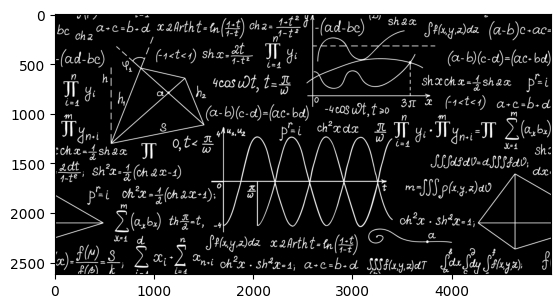

In [4]:
newImg_BGR = cv2.imread('mathematics.jpg')  
newImg_RGB = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2RGB)

plt.imshow(newImg_RGB)
# plt.imshow(newImg2_RGB)


Convert the image to grayscale.

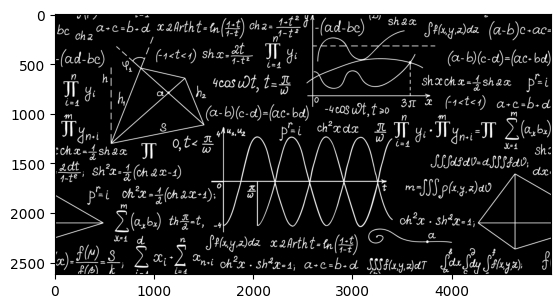

In [5]:
newImg_Gray = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2GRAY)
plt.imshow(newImg_Gray, cmap='gray')

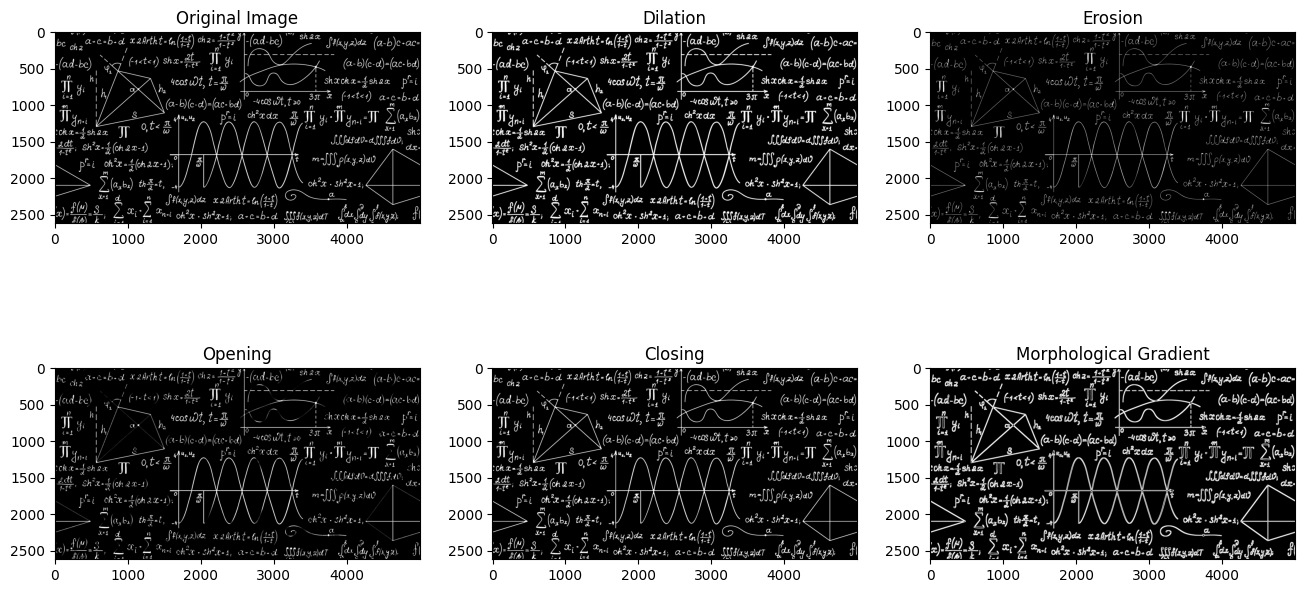

In [6]:
# ## 1. Morphological Operations
#   - For each morphological method below,
#     Find one image from the internet in which the effect of the method is clearly visible, then apply the method:
#         (a) Dilation
#         (b) Erosion
#         (c) Opening
#         (d) Closing
#         (e) Morphological Gradient

#   - For each operator:
#       - Show the original image
#       - Choose an appropriate structuring element
#       (e.g., cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))
#       - Show the processed image
#       - Explain in 3–5 sentences why the result looks the way it does

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
kernel2 = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
dilation = cv2.dilate(newImg_Gray, kernel, iterations=1)
erosion = cv2.erode(newImg_Gray, kernel, iterations=1)
opening = cv2.morphologyEx(newImg_Gray, cv2.MORPH_OPEN, kernel2)
closing = cv2.morphologyEx(newImg_Gray, cv2.MORPH_CLOSE, kernel2)
morph_gradient = cv2.morphologyEx(newImg_Gray, cv2.MORPH_GRADIENT, kernel2)

plt.figure(figsize=(16, 8))
plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(newImg_Gray, cmap='gray')
plt.subplot(2, 3, 2)
plt.title('Dilation')
plt.imshow(dilation, cmap='gray')
plt.subplot(2, 3, 3)
plt.title('Erosion')
plt.imshow(erosion, cmap='gray')
plt.subplot(2, 3, 4)
plt.title('Opening')
plt.imshow(opening, cmap='gray')
plt.subplot(2, 3, 5)
plt.title('Closing')
plt.imshow(closing, cmap='gray')
plt.subplot(2, 3, 6)
plt.title('Morphological Gradient')
plt.imshow(morph_gradient, cmap='gray')
plt.show()

# - Explain in 3–5 sentences each transform why the result looks the way it does
# Dilation: This operation adds pixels to the boundaries of objects in an image. The structuring element used here is an ellipse, which causes the bright regions to expand outward, filling in small holes and connecting nearby objects. This is particularly useful for enhancing features in binary images.
# Erosion: This operation removes pixels from the boundaries of objects. Using the same elliptical structuring element, erosion shrinks bright regions, effectively removing small noise and separating connected objects. It is useful for eliminating small artifacts in images.
# Opening: This operation is a combination of erosion followed by dilation. It is effective for removing small objects from the foreground while preserving the shape and size of larger objects. The rectangular structuring element helps to smooth the contours of objects and eliminate noise.
# Closing: This operation is the reverse of opening, consisting of dilation followed by erosion. It is useful for closing small holes and gaps in the foreground objects. The rectangular structuring element helps to fill in small dark regions within bright objects, enhancing their overall appearance.
# Morphological Gradient: This operation computes the difference between the dilation and erosion of an image.

## 2. Morphology Applications
- (a) License Plate Character Extraction
    - Find an image of a vehicle license plate
    - Use a combination of morphological operations
    (e.g., closing → opening → gradient → thresholding)
    - Extract and isolate the individual characters
    - Display:
        - Preprocessing steps
        - Intermediate morphology results
        - Final segmented characters

- (b) Storefront Signboard Text Extraction
    - Find a picture of a shop sign / storefront
    - Combine morphology + thresholding to:
        - Remove background clutter
        - Highlight the text regions
        - Extract meaningful information such as:
        Shop name, phone number, address, promotions, etc.
    - Document your full pipeline

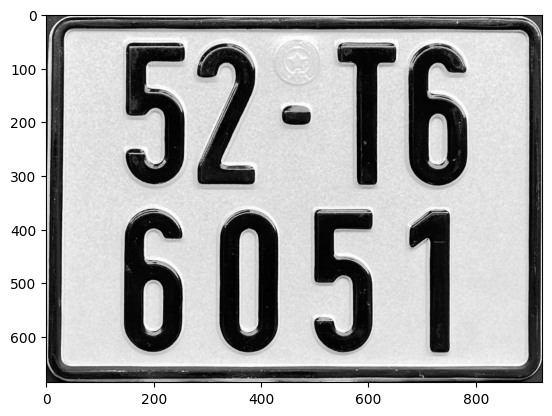

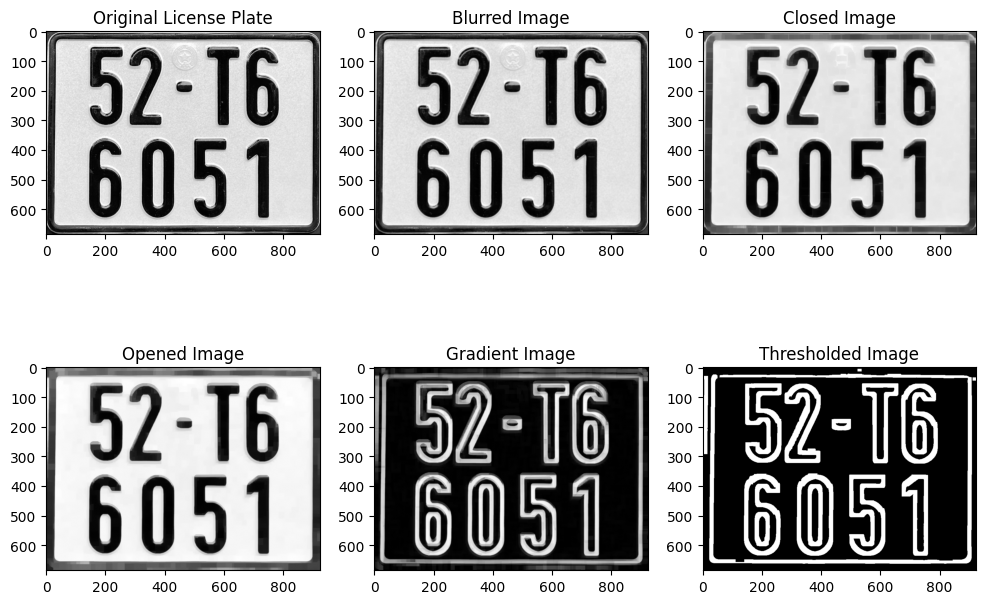

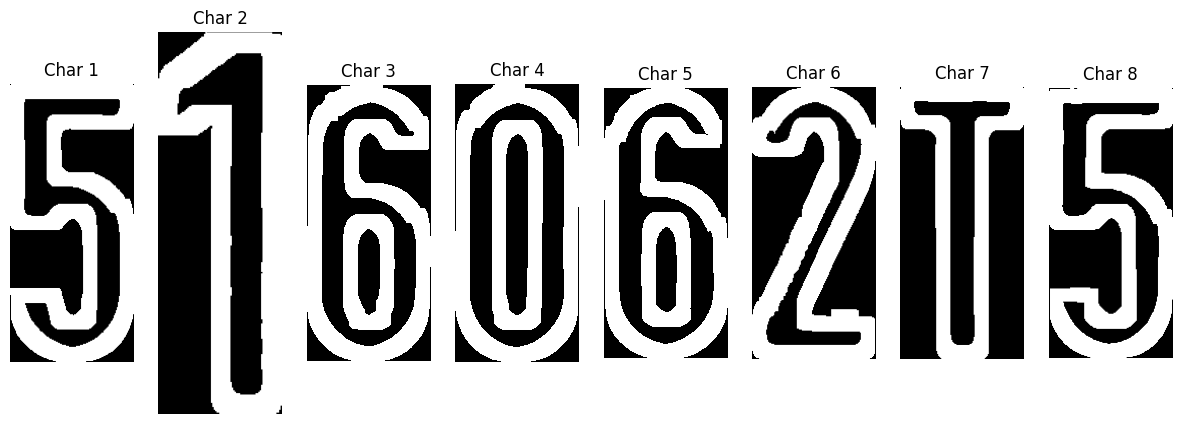

In [27]:
# 2. Morphology Applications
#   (a) License Plate Character Extraction

#     - Find an image of a vehicle license plate

#     - Use a combination of morphological operations
#     (e.g., closing → opening → gradient → thresholding)

#     - Extract and isolate the individual characters

#     - Display:
#       - Preprocessing steps
#       - Intermediate morphology results
#       - Final segmented characters


license_plate_img = cv2.imread('license_plate.jpg')
license_plate_gray = cv2.cvtColor(license_plate_img, cv2.COLOR_BGR2GRAY)
plt.imshow(license_plate_gray, cmap='gray')
# Preprocessing: Gaussian Blur
blurred = cv2.GaussianBlur(license_plate_gray, (5, 5), 0)
# Morphological Operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
closed = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel)
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
gradient = cv2.morphologyEx(opened, cv2.MORPH_GRADIENT, kernel)
# Thresholding
_, thresh = cv2.threshold(gradient, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# Find contours of the characters
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Draw bounding boxes around characters
character_images = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if h > 30 and w > 10:  # Filter out small contours
        char_img = thresh[y:y+h, x:x+w]
        character_images.append(char_img)
        cv2.rectangle(license_plate_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
# Display results
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.title('Original License Plate')
plt.imshow(license_plate_gray, cmap='gray')
plt.subplot(2, 3, 2)
plt.title('Blurred Image')
plt.imshow(blurred, cmap='gray')
plt.subplot(2, 3, 3)
plt.title('Closed Image')
plt.imshow(closed, cmap='gray')
plt.subplot(2, 3, 4)
plt.title('Opened Image')
plt.imshow(opened, cmap='gray')
plt.subplot(2, 3, 5)
plt.title('Gradient Image')
plt.imshow(gradient, cmap='gray')
plt.subplot(2, 3, 6)
plt.title('Thresholded Image')
plt.imshow(thresh, cmap='gray')
plt.show()

# filter out abnormal character images by calculating mean width and height
widths = [img.shape[1] for img in character_images]
heights = [img.shape[0] for img in character_images]
mean_width = np.mean(widths)
mean_height = np.mean(heights)
filtered_character_images = []
for img in character_images:
    if (0.3 * mean_width < img.shape[1] < 1.5 * mean_width) and (0.5 * mean_height < img.shape[0] < 1.5 * mean_height):
        filtered_character_images.append(img)

        
# Display extracted characters in an image
num_chars = len(filtered_character_images)
plt.figure(figsize=(15, 5))
for i, char_img in enumerate(filtered_character_images):
    plt.subplot(1, num_chars, i + 1)
    plt.title(f'Char {i+1}')
    plt.imshow(char_img, cmap='gray')
    plt.axis('off')
plt.show()

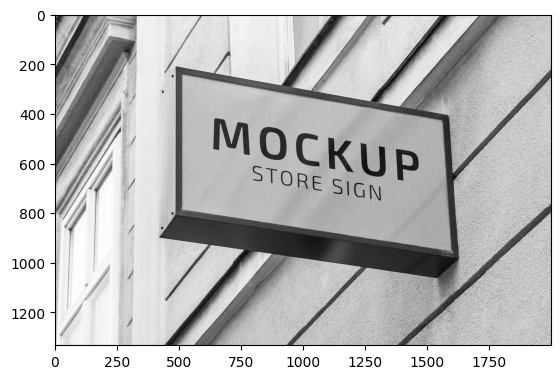

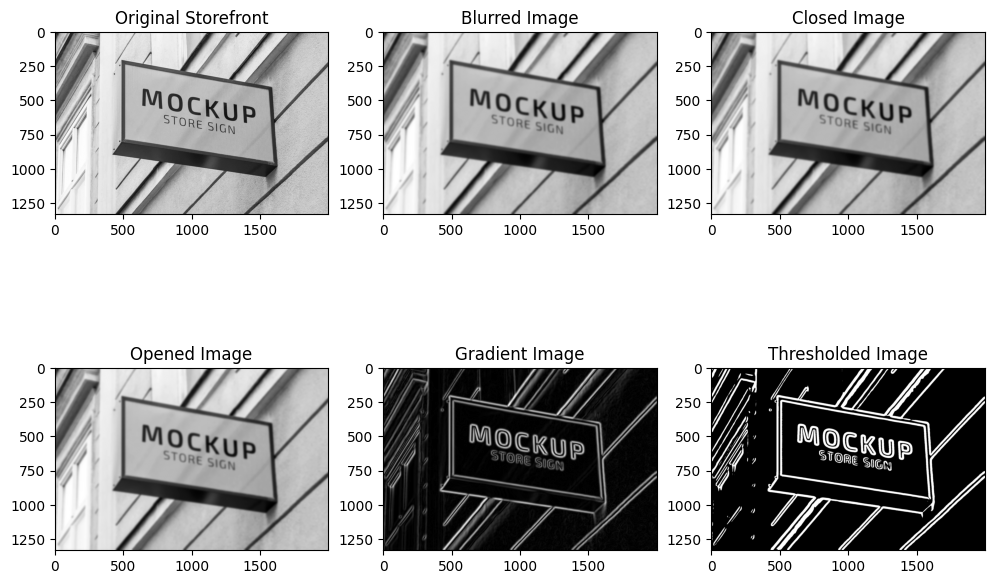

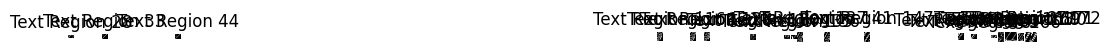

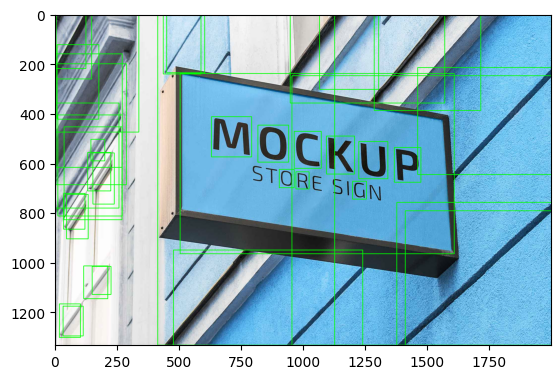

In [ ]:
#  (b) Storefront Signboard Text Extraction

#     - Find a picture of a shop sign / storefront

#     - Combine morphology + thresholding to:
#       - Remove background clutter
#       - Highlight the text regions
#       - Extract meaningful information such as:
#       Shop name, phone number, address, promotions, etc.

#     - Document your full pipeline
storefront_img = cv2.imread('storefront.jpg')
storefront_gray = cv2.cvtColor(storefront_img, cv2.COLOR_BGR2GRAY)
plt.imshow(storefront_gray, cmap='gray')
# Preprocessing: Gaussian Blur

blurred_storefront = cv2.GaussianBlur(storefront_gray, (35, 35), 0)
# Morphological Operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
closed_storefront = cv2.morphologyEx(blurred_storefront, cv2.MORPH_CLOSE, kernel)
opened_storefront = cv2.morphologyEx(closed_storefront, cv2.MORPH_OPEN, kernel2)
gradient_storefront = cv2.morphologyEx(opened_storefront, cv2.MORPH_GRADIENT, kernel2)

# Thresholding
_, thresh_storefront = cv2.threshold(gradient_storefront, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# Find contours of the text regions                                         
contours_storefront, _ = cv2.findContours(thresh_storefront, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Draw bounding boxes around text regions
for cnt in contours_storefront:
    x, y, w, h = cv2.boundingRect(cnt)
    if h > 50 and w > 50:  # Filter out small contours
        cv2.rectangle(storefront_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        
# Display results
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.title('Original Storefront')
plt.imshow(storefront_gray, cmap='gray')
plt.subplot(2, 3, 2)
plt.title('Blurred Image')
plt.imshow(blurred_storefront, cmap='gray')
plt.subplot(2, 3, 3)
plt.title('Closed Image')
plt.imshow(closed_storefront, cmap='gray')
plt.subplot(2, 3, 4)
plt.title('Opened Image')
plt.imshow(opened_storefront, cmap='gray')
plt.subplot(2, 3, 5)
plt.title('Gradient Image')
plt.imshow(gradient_storefront, cmap='gray')
plt.subplot(2, 3, 6)
plt.title('Thresholded Image')
plt.imshow(thresh_storefront, cmap='gray')
plt.show()

